# 04 — Analysis: Metrics and Plots

Combine central and federated k-means results, compute final metrics,
and generate comparison plots.

**What this notebook does:**
1. Load central k-means results from notebook 02.
2. Load federated k-means results from notebook 03 (if available).
3. Compute ARI, MCC, accuracy for all (method x target) combinations.
4. Generate ARI bar charts, PCA comparison plots, multi-dataset summary.

**Prerequisites:** Run notebooks 01 and 02. Notebook 03 is optional.

## Imports

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from evaluation_utils.real_datasets_utils import (
    dataset_configs,
    evaluate_metrics,
    load_fed_metadata,
    save_metrics_tables,
    load_feature_matrix,
)

def display_styled_or_plain(df, make_styler):
    try:
        display(make_styler(df))
    except AttributeError as exc:
        if "requires jinja2" not in str(exc):
            raise
        display(df)

## Configuration

In [2]:
DATASETS = [
    "ecoli", 
    "ovarian_cancer", 
    "quartet", "ccRCC_proteomics", "multiomics"]
OUTPUT_ROOT = NOTEBOOK_DIR

# Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

## Load Results and Compute Metrics

In [3]:
all_metrics = []
dataset_data = {}  # store loaded data for PCA plots
configs = dataset_configs(REPO_ROOT)

for ds_name in DATASETS:
    ds_dir = OUTPUT_ROOT / ds_name
    run_dir = ds_dir / "kmeans_res" / "runs"

    # Load central results (from notebook 02)
    central_path = run_dir / "1_metadata_cntrl_kmeans_res.tsv"
    if not central_path.exists():
        print(f"[{ds_name}] Central results not found — run notebook 02 first.")
        continue
    central_res = pd.read_csv(central_path, sep="\t")

    # Load federated results (from notebook 03, optional)
    before_fed = load_fed_metadata(run_dir / "1_metadata_before_fedclusters.tsv")
    after_fed = load_fed_metadata(run_dir / "1_metadata_after_fedclusters.tsv")

    k_condition = int(central_res['condition'].nunique())
    k_batch = int(central_res['lab'].nunique())

    print(f"\n{'='*60}")
    print(f"{ds_name}: k_condition={k_condition}, k_batch={k_batch}")
    if before_fed is not None:
        print(f"  Federated before: {before_fed.shape[0]} samples")
    if after_fed is not None:
        print(f"  Federated after: {after_fed.shape[0]} samples")

    metrics = evaluate_metrics(
        dataset_name=ds_name,
        central_res=central_res,
        before_fed_res=before_fed,
        after_fed_res=after_fed,
        k_condition=k_condition,
        k_batch=k_batch,
    )
    all_metrics.append(metrics)

    # Also store matrices for PCA
    prepared_dir = ds_dir / "prepared"
    dataset_data[ds_name] = {
        'before': load_feature_matrix(prepared_dir / "before_matrix.tsv"),
        'corrected': load_feature_matrix(prepared_dir / "corrected_matrix.tsv"),
        'metadata': central_res,
        'before_fed': before_fed,
        'after_fed': after_fed,
        'k_condition': k_condition,
        'k_batch': k_batch,
    }

combined_metrics = pd.concat(all_metrics, ignore_index=True)
save_metrics_tables(combined_metrics, OUTPUT_ROOT)
print(f"\nCombined metrics saved to {OUTPUT_ROOT}")


ecoli: k_condition=2, k_batch=5
  Federated before: 118 samples
  Federated after: 118 samples

ovarian_cancer: k_condition=2, k_batch=6
  Federated before: 332 samples
  Federated after: 332 samples

quartet: k_condition=4, k_batch=4
  Federated before: 72 samples
  Federated after: 72 samples

ccRCC_proteomics: k_condition=2, k_batch=3
  Federated before: 887 samples
  Federated after: 887 samples

multiomics: k_condition=4, k_batch=3
  Federated before: 48 samples
  Federated after: 48 samples

Combined metrics saved to /home/yuliya-cosybio/repos/cosybio/fedRBE/evaluation_clusterization_after_correction/real_datasets


## Metrics Table

In [4]:
# Display full metrics table with ARI heatmap coloring.
display_cols = ["Dataset", "Target", "K", "Method", "ARI", "N"]
metrics_table = combined_metrics[display_cols].copy()
display_styled_or_plain(
    metrics_table,
    lambda df: df.style.format({"ARI": "{:.3f}"}).background_gradient(
        subset=["ARI"], cmap="RdYlGn", vmin=-0.1, vmax=1
    ),
)

,Dataset,Target,K,Method,ARI,N
0,ecoli,condition,2,ecoli_condition_BC_Cntrl_2cls,-0.005105,118
1,ecoli,condition,2,ecoli_condition_AC_Cntrl_2cls,1.000000,118
2,ecoli,condition,2,ecoli_condition_BC_Fed_2cls,-0.001377,118
3,ecoli,condition,2,ecoli_condition_AC_Fed_2cls,1.000000,118
4,ecoli,batch,5,ecoli_batch_BC_Cntrl_5cls,1.000000,118
5,ecoli,batch,5,ecoli_batch_AC_Cntrl_5cls,-0.008350,118
6,ecoli,batch,5,ecoli_batch_BC_Fed_5cls,0.116547,118
7,ecoli,batch,5,ecoli_batch_AC_Fed_5cls,-0.011143,118
8,ovarian_cancer,condition,2,ovarian_cancer_condition_BC_Cntrl_2cls,0.108155,332
9,ovarian_cancer,condition,2,ovarian_cancer_condition_AC_Cntrl_2cls,0.139814,332


## Plot Style

Publication-quality constants, colour palette, and helper functions used by all figures below.

In [5]:
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ── rcParams applied via mpl.rc_context inside every plot function ────────────
PUB_RC = {
    "font.family":       "sans-serif",
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.labelsize":    9,
    "xtick.labelsize":   8.5,
    "ytick.labelsize":   8.5,
    "legend.fontsize":   8,
    "legend.framealpha": 0.9,
    "legend.edgecolor":  "#cccccc",
    "legend.borderpad":  0.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "axes.grid.axis":    "y",
    "grid.alpha":        0.3,
    "grid.linewidth":    0.6,
    "grid.color":        "#bbbbbb",
    "figure.dpi":        100,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
}

# Colorblind-safe palette (RdBu-derived): light = Central, dark = Federated
# Blue tones = Before correction; Orange/Red tones = After correction
METHODS_ORDER = ["BC_Cntrl", "AC_Cntrl", "BC_Fed", "AC_Fed"]
METHOD_META = {
    "BC_Cntrl": dict(label="Before — Central",   color="#92c5de", hatch=""),
    "AC_Cntrl": dict(label="After — Central",    color="#f4a582", hatch=""),
    "BC_Fed":   dict(label="Before — Federated", color="#0571b0", hatch="///"),
    "AC_Fed":   dict(label="After — Federated",  color="#ca0020", hatch="///"),
}

DATASET_LABELS = {
    "ecoli":            "E. coli",
    "ovarian_cancer":            "Ovarian cancer",
    "quartet": "Multi-batch",
    "ccRCC_proteomics":      "ccRCC",
    "multiomics":      "Multi-omics",
}
TARGET_LABELS = {"condition": "Condition", "batch": "Batch"}


def extract_method_key(method_name: str) -> str:
    for key in METHODS_ORDER:
        if key in method_name:
            return key
    return "Unknown"


## ARI Comparison

All datasets side-by-side; Condition (left) and Batch (right) targets.
Dashed vertical lines separate dataset groups. Hatching = federated.

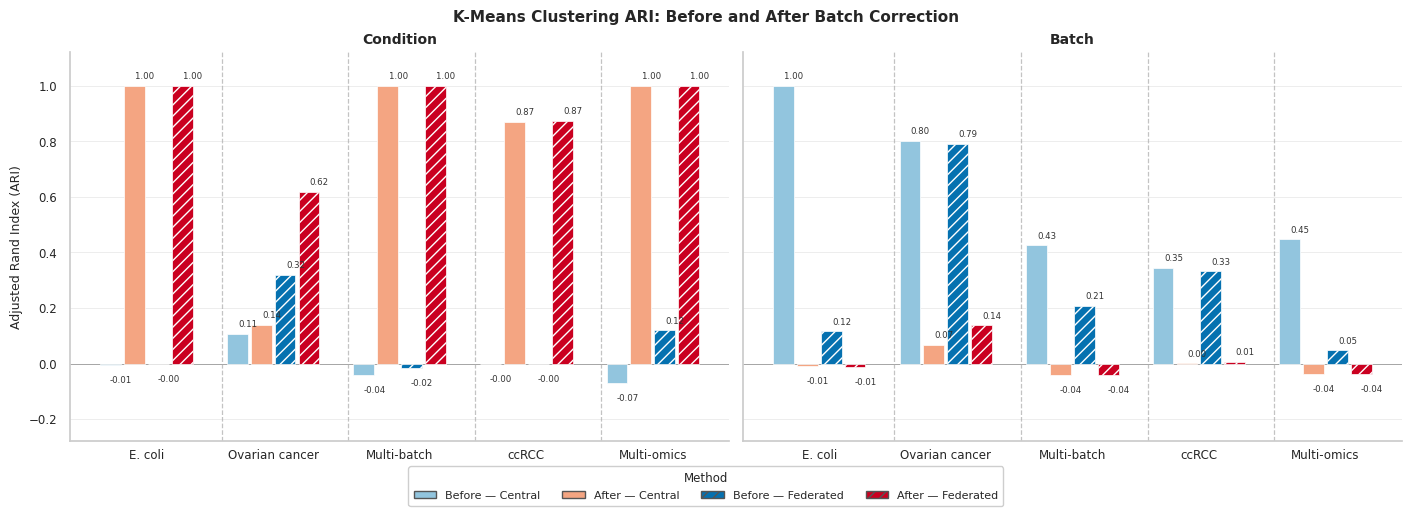

In [6]:
def plot_ari_grouped(metrics_df, datasets, save_path=None):
    """Publication-quality ARI grouped bar chart.

    Two subplots (Condition | Batch); dataset groups separated by dashed vertical
    lines; ARI values annotated above/below each bar.
    """
    df = metrics_df.copy()
    df["MethodKey"] = df["Method"].apply(extract_method_key)
    present_methods = [m for m in METHODS_ORDER if m in df["MethodKey"].values]
    present_ds = [ds for ds in datasets if ds in df["Dataset"].values]
    n_m = len(present_methods)
    bar_w = 0.17
    group_gap = 0.22
    group_w = n_m * bar_w + group_gap

    with mpl.rc_context(PUB_RC):
        fig_w = max(7.0, len(present_ds) * group_w * 4.5 + 2.0)
        fig, axes = plt.subplots(
            1, 2,
            figsize=(min(fig_w, 14), 4.6),
            sharey=True,
            constrained_layout=True,
        )

        for ax_idx, target in enumerate(["condition", "batch"]):
            ax = axes[ax_idx]
            tdf = df[df["Target"] == target]
            xtick_pos, xtick_labels = [], []

            for ds_idx, ds_name in enumerate(present_ds):
                ddf = tdf[tdf["Dataset"] == ds_name]
                x0 = ds_idx * group_w

                for m_idx, mk in enumerate(present_methods):
                    mdf = ddf[ddf["MethodKey"] == mk]
                    if mdf.empty:
                        continue
                    ari = float(mdf["ARI"].iloc[0])
                    x = x0 + m_idx * bar_w
                    ax.bar(
                        x, ari,
                        width=bar_w * 0.87,
                        color=METHOD_META[mk]["color"],
                        hatch=METHOD_META[mk]["hatch"],
                        edgecolor="white", linewidth=0.5, zorder=3,
                        label=METHOD_META[mk]["label"] if ds_idx == 0 else None,
                    )
                    yoff = 0.018 if ari >= 0 else -0.04
                    va = "bottom" if ari >= 0 else "top"
                    ax.text(
                        x + bar_w * 0.435, ari + yoff, f"{ari:.2f}",
                        ha="center", va=va, fontsize=6.2,
                        color="#333333", zorder=5,
                    )

                center = x0 + (n_m - 1) * bar_w / 2
                xtick_pos.append(center)
                xtick_labels.append(DATASET_LABELS.get(ds_name, ds_name))

                if ds_idx < len(present_ds) - 1:
                    ax.axvline(
                        x0 + n_m * bar_w + group_gap / 2,
                        color="#aaaaaa", lw=0.9, ls="--", alpha=0.7, zorder=2,
                    )

            ax.axhline(0, color="black", lw=0.6, alpha=0.35, zorder=1)
            ax.set_ylim(-0.28, 1.12)
            ax.set_xticks(xtick_pos)
            ax.set_xticklabels(xtick_labels, fontsize=8.5, multialignment="center")
            ax.tick_params(axis="x", length=0, pad=5)
            ax.set_title(TARGET_LABELS[target], fontweight="bold", pad=6)
            if ax_idx == 0:
                ax.set_ylabel("Adjusted Rand Index (ARI)")

        legend_handles = [
            Patch(
                facecolor=METHOD_META[mk]["color"],
                hatch=METHOD_META[mk]["hatch"],
                edgecolor="#555555",
                label=METHOD_META[mk]["label"],
            )
            for mk in present_methods
        ]
        fig.legend(
            handles=legend_handles,
            loc="lower center", ncol=len(present_methods),
            bbox_to_anchor=(0.5, -0.10),
            framealpha=0.95, edgecolor="#cccccc",
            title="Method", title_fontsize=8.5,
        )
        fig.suptitle(
            "K-Means Clustering ARI: Before and After Batch Correction",
            fontweight="bold", fontsize=11,
        )
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
    return fig


fig_ari = plot_ari_grouped(combined_metrics, DATASETS)

## PCA: Before vs. After Correction

2 × 2 grid per dataset: rows = Before / After correction; columns = Condition / Batch true labels.

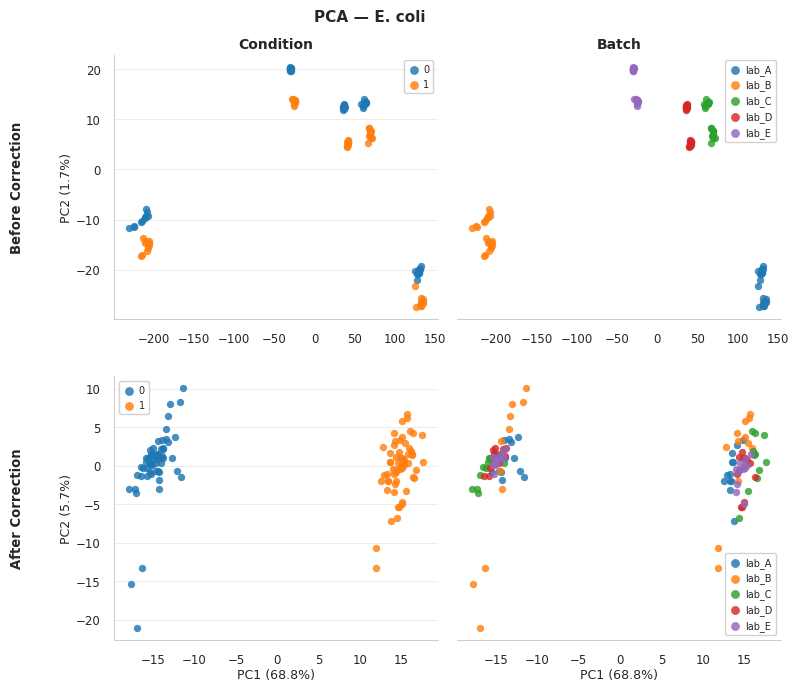

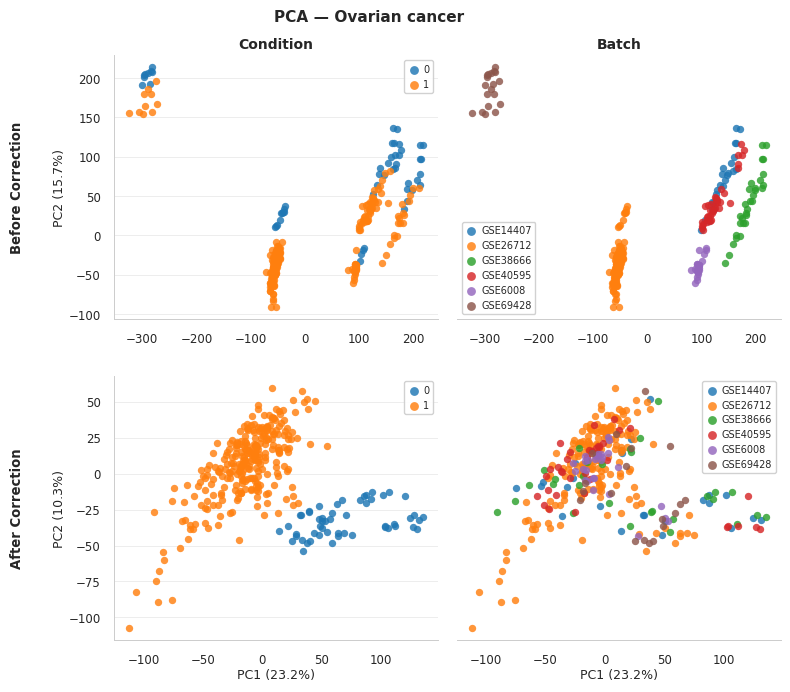

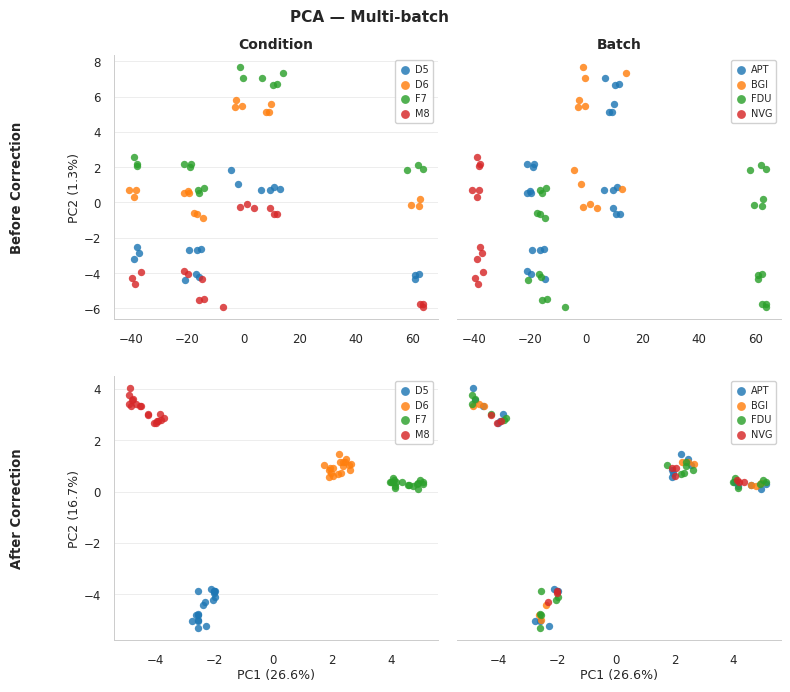

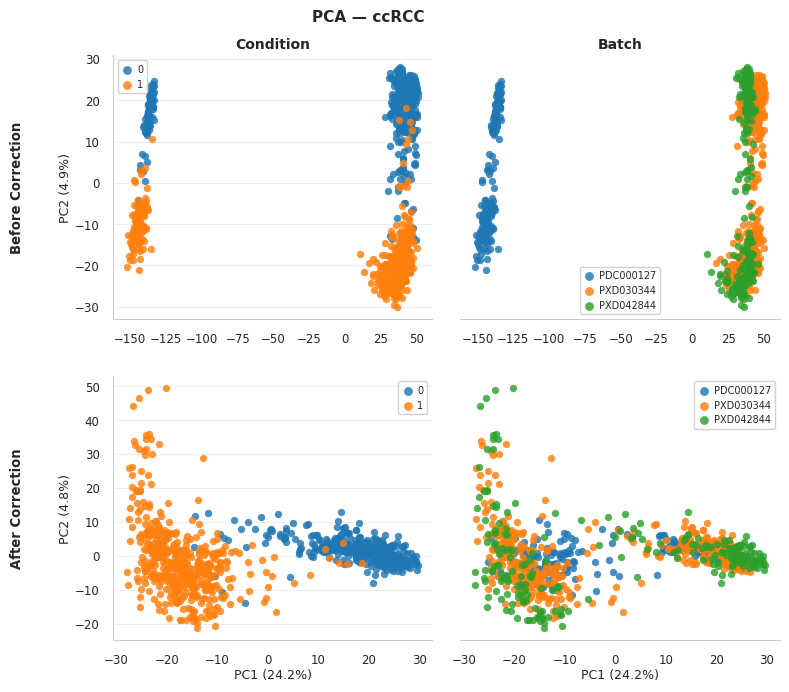

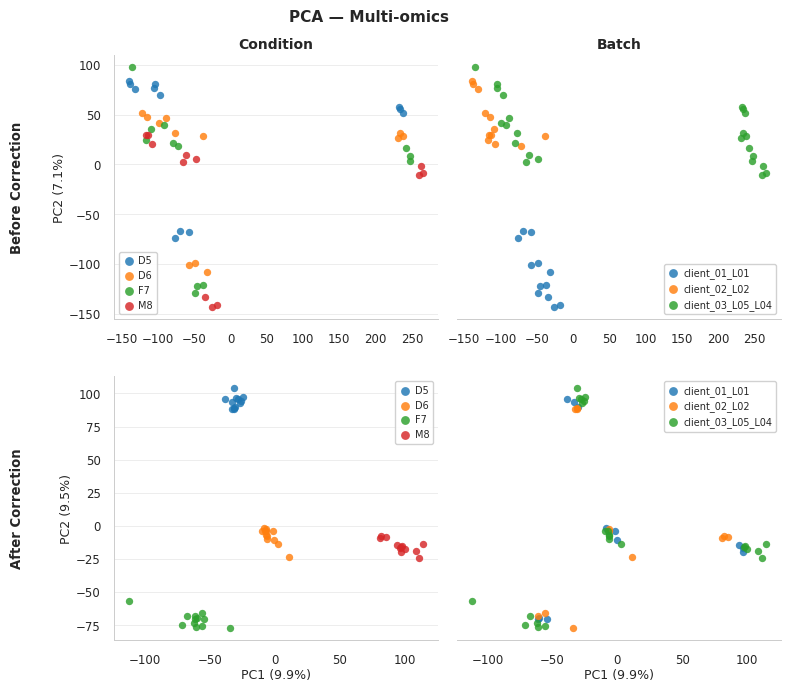

In [7]:
def plot_pca_dataset(ds_name, data_dict, save_path=None):
    """2×2 PCA grid per dataset: rows = Before/After; cols = Condition/Batch true labels."""
    row_specs = [
        ("before",    "Before Correction"),
        ("corrected", "After Correction"),
    ]
    col_specs = [
        ("condition", "Condition"),
        ("lab",       "Batch"),
    ]

    with mpl.rc_context(PUB_RC):
        # sharex/sharey='row': both columns in a row share the same PCA space
        fig, axes = plt.subplots(
            2, 2, figsize=(8.5, 7.0),
            sharex="row", sharey="row",
        )

        # Pre-compute PCA coords for each matrix (before / corrected)
        row_cache = {}
        for row_idx, (mat_key, _) in enumerate(row_specs):
            mat = data_dict[mat_key]
            arr = mat.to_numpy(dtype=float).T
            arr = arr - np.nanmean(arr, axis=0, keepdims=True)
            pca_obj = PCA(n_components=2)
            coords = pca_obj.fit_transform(arr)
            var_pct = pca_obj.explained_variance_ratio_ * 100
            row_cache[row_idx] = (mat, coords, var_pct)

        for row_idx, (mat_key, row_label) in enumerate(row_specs):
            mat, coords, var_pct = row_cache[row_idx]
            sample_order = list(mat.columns)
            meta = data_dict["metadata"]
            if "file" in meta.columns:
                meta_aligned = meta.set_index("file").reindex(sample_order)
            else:
                meta_aligned = meta.copy()

            for col_idx, (col, col_label) in enumerate(col_specs):
                ax = axes[row_idx, col_idx]

                if col not in meta_aligned.columns:
                    ax.text(0.5, 0.5, "N/A", ha="center", va="center",
                            transform=ax.transAxes, color="gray")
                    if row_idx == 0:
                        ax.set_title(col_label, fontweight="bold", pad=5)
                    continue

                # Drop NaN before astype to avoid spurious "nan" group
                raw_labels = meta_aligned[col].dropna()
                str_labels = meta_aligned[col].where(meta_aligned[col].notna()).map(
                    lambda v: str(v) if pd.notna(v) else None
                )
                unique_labels = sorted(raw_labels.astype(str).unique())
                palette = sns.color_palette("tab10", n_colors=max(len(unique_labels), 3))
                color_map = dict(zip(unique_labels, palette))

                for grp in unique_labels:
                    mask = (str_labels == grp).fillna(False).to_numpy()
                    ax.scatter(
                        coords[mask, 0], coords[mask, 1],
                        color=color_map[grp],   # FIX: use color= not c=
                        label=grp,
                        alpha=0.82, s=28, linewidths=0, zorder=3,
                    )

                # x-label only on bottom row; y-label only on left column
                if row_idx == len(row_specs) - 1:
                    ax.set_xlabel(f"PC1 ({var_pct[0]:.1f}%)", labelpad=2)
                if col_idx == 0:
                    ax.set_ylabel(f"PC2 ({var_pct[1]:.1f}%)", labelpad=2)
                if row_idx == 0:
                    ax.set_title(col_label, fontweight="bold", pad=5)

                ax.spines["left"].set_linewidth(0.7)
                ax.spines["bottom"].set_linewidth(0.7)

                # Legend on every subplot so each column's groups are labeled
                ax.legend(
                    fontsize=7, loc="best", markerscale=1.2,
                    framealpha=0.9, handlelength=1.2,
                    borderpad=0.4, handletextpad=0.4,
                )

                # Hide y-axis ticks/labels on right column (shared with left)
                if col_idx == 1:
                    ax.yaxis.set_visible(False)
                    ax.spines["left"].set_visible(False)

            # Row label rotated on the far left
            axes[row_idx, 0].annotate(
                row_label,
                xy=(-0.30, 0.5), xycoords="axes fraction",
                rotation=90, va="center", ha="center",
                fontsize=9.5, fontweight="bold", annotation_clip=False,
            )

        fig.suptitle(
            f"PCA — {DATASET_LABELS.get(ds_name, ds_name)}",
            fontweight="bold", fontsize=11,
        )
        fig.tight_layout(rect=[0.07, 0, 1, 1], h_pad=2.5, w_pad=1.5)
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
    return fig


for ds_name, data in dataset_data.items():
    plot_pca_dataset(ds_name, data)

## ARI: Before vs. After Correction (Scatter)

Each point = one (dataset × target) pair. Points above the diagonal indicate
improvement after batch correction. Color = target; marker = dataset.

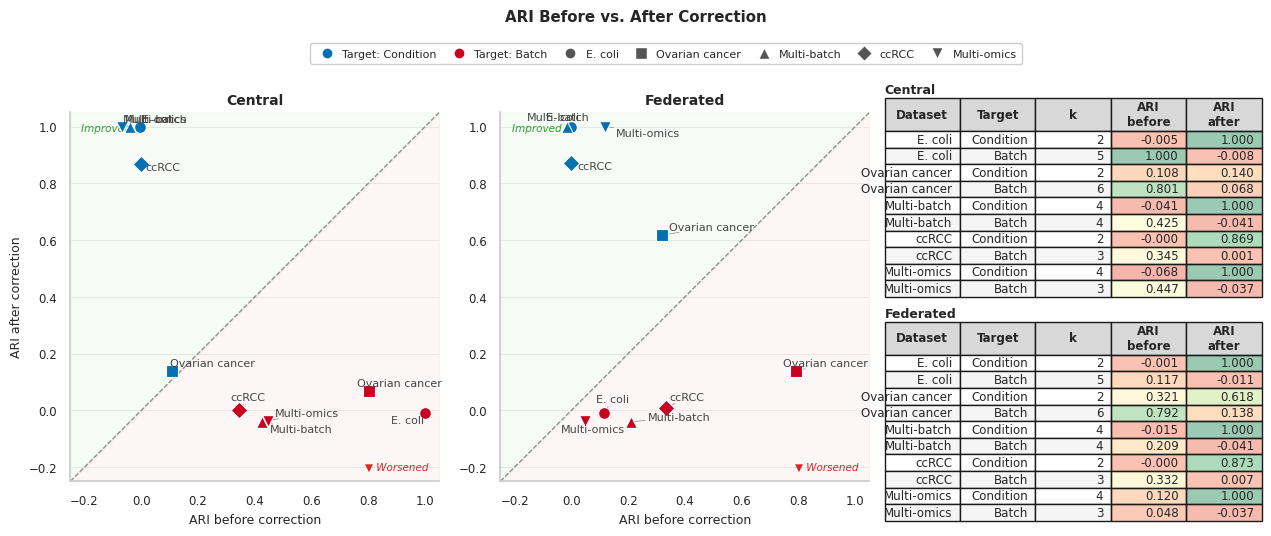

In [8]:
from adjustText import adjust_text

def plot_ari_scatter(metrics_df, datasets, save_path=None):
    """ARI before (x) vs after (y) scatter with summary tables on the right.

    Layout:
      [Legend — horizontal, spanning all columns          ]
      [Central scatter] [Federated scatter] [Central table]
                                            [Fed table    ]
    """
    df = metrics_df.copy()
    df["MethodKey"] = df["Method"].apply(extract_method_key)
    has_fed = {"BC_Fed", "AC_Fed"}.issubset(set(df["MethodKey"].values))
    variants = [("Central", "BC_Cntrl", "AC_Cntrl")]
    if has_fed:
        variants.append(("Federated", "BC_Fed", "AC_Fed"))

    TARGET_COLORS = {"condition": "#0571b0", "batch": "#ca0020"}
    marker_cycle = ["o", "s", "^", "D", "v", "P", "X"]
    DS_MARKERS = {ds: marker_cycle[i % len(marker_cycle)]
                  for i, ds in enumerate(datasets)}
    present_ds = [ds for ds in datasets if ds in df["Dataset"].values]

    def build_table_data(bk, ak):
        rows = []
        for ds_name in present_ds:
            for target in ["condition", "batch"]:
                tdf = df[(df["Dataset"] == ds_name) & (df["Target"] == target)]
                brow = tdf[tdf["MethodKey"] == bk]
                arow = tdf[tdf["MethodKey"] == ak]
                if brow.empty or arow.empty:
                    continue
                rows.append([
                    DATASET_LABELS.get(ds_name, ds_name).replace("\n", " "),
                    TARGET_LABELS[target],
                    str(int(brow["K"].iloc[0])),
                    f"{float(brow['ARI'].iloc[0]):.3f}",
                    f"{float(arow['ARI'].iloc[0]):.3f}",
                ])
        return rows

    col_labels = ["Dataset", "Target", "k", "ARI\nbefore", "ARI\nafter"]
    n_scatter = len(variants)
    tbl_col_w = 4
    tbl_font  = 8.5
    data_row_h = 0.02
    header_row_h = 0.04

    with mpl.rc_context(PUB_RC):
        fig_w = 4 * n_scatter + tbl_col_w + 0.6
        fig_h = 5.2
        fig = plt.figure(figsize=(fig_w, fig_h), layout="constrained")

        outer_gs = fig.add_gridspec(
            2, n_scatter + 1,
            height_ratios=[0.10, 1.0],
            width_ratios=[4.4] * n_scatter + [tbl_col_w],
        )

        # ── Legend: horizontal, spanning all columns ───────────────────────────
        ax_leg = fig.add_subplot(outer_gs[0, :])
        ax_leg.axis("off")
        legend_elems = [
            Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=TARGET_COLORS[t], markersize=8,
                   label=f"Target: {TARGET_LABELS[t]}")
            for t in ["condition", "batch"]
        ]
        for ds_name in present_ds:
            legend_elems.append(
                Line2D([0], [0],
                       marker=DS_MARKERS.get(ds_name, "o"),
                       color="w", markerfacecolor="#555555", markersize=8,
                       label=DATASET_LABELS.get(ds_name, ds_name).replace("\n", " "))
            )
        ax_leg.legend(
            handles=legend_elems,
            loc="center",
            ncol=len(legend_elems),
            bbox_to_anchor=(0.5, 0.5),
            framealpha=0.95, edgecolor="#cccccc", fontsize=8,
            borderpad=0.5, columnspacing=1.0, handletextpad=0.4,
        )

        # ── Scatter plots ──────────────────────────────────────────────────────
        for col, (title, bk, ak) in enumerate(variants):
            ax = fig.add_subplot(outer_gs[1, col])
            scatter_xs, scatter_ys = [], []
            texts = []

            for target in ["condition", "batch"]:
                tdf = df[df["Target"] == target]
                for ds_name in present_ds:
                    ddf = tdf[tdf["Dataset"] == ds_name]
                    brow = ddf[ddf["MethodKey"] == bk]
                    arow = ddf[ddf["MethodKey"] == ak]
                    if brow.empty or arow.empty:
                        continue
                    x = float(brow["ARI"].iloc[0])
                    y = float(arow["ARI"].iloc[0])
                    scatter_xs.append(x)
                    scatter_ys.append(y)
                    ax.scatter(
                        x, y,
                        color=TARGET_COLORS[target],
                        marker=DS_MARKERS.get(ds_name, "o"),
                        s=72, zorder=4, linewidths=0.8, edgecolors="white",
                    )
                    texts.append(ax.text(
                        x, y,
                        DATASET_LABELS.get(ds_name, ds_name).replace("\n", " "),
                        fontsize=8, color="#444444", zorder=5,
                    ))

            lo, hi = -0.25, 1.05
            ax.plot([lo, hi], [lo, hi], color="#888888", lw=0.9, ls="--", zorder=2)
            ax.fill_between([lo, hi], [lo, hi], [hi, hi],
                            alpha=0.04, color="#2ca02c", zorder=1)
            ax.fill_between([lo, hi], [lo, lo], [lo, hi],
                            alpha=0.04, color="#d62728", zorder=1)
            ax.text(0.03, 0.97, "Improved ▲", transform=ax.transAxes,
                    color="#2ca02c", fontsize=7.5, va="top", fontstyle="italic")
            ax.text(0.97, 0.03, "▼ Worsened", transform=ax.transAxes,
                    color="#d62728", fontsize=7.5, ha="right", fontstyle="italic")
            ax.set_xlim(lo, hi)
            ax.set_ylim(lo, hi)
            ax.set_xlabel("ARI before correction")
            ax.set_ylabel("ARI after correction" if col == 0 else "")
            ax.set_title(title, fontweight="bold")
            ax.set_aspect("equal", adjustable="box")

            # Repel labels away from each other and from their points
            if texts:
                adjust_text(
                    texts,
                    x=scatter_xs, y=scatter_ys,
                    ax=ax,
                    expand=(1.3, 1.5),
                    arrowprops=dict(arrowstyle="-", color="#999999", lw=0.6),
                )

        # ── Right panel: one table per variant, tightly stacked ───────────────
        inner_gs = outer_gs[1, n_scatter].subgridspec(
            len(variants), 1,
            hspace=0.04,
        )
        for tbl_idx, (title, bk, ak) in enumerate(variants):
            ax_tbl = fig.add_subplot(inner_gs[tbl_idx])
            ax_tbl.axis("off")
            rows = build_table_data(bk, ak)
            if rows:
                tbl = ax_tbl.table(
                    cellText=rows,
                    colLabels=col_labels,
                    loc="upper center",
                    bbox=[0, 0, 1, 1],
                )
                tbl.auto_set_font_size(False)
                tbl.set_fontsize(tbl_font)
                for j in range(len(col_labels)):
                    tbl[0, j].set_height(header_row_h)
                    tbl[0, j].set_facecolor("#d8d8d8")
                    tbl[0, j].set_text_props(fontweight="bold")
                for row_i, row in enumerate(rows, start=1):
                    bg = "#f5f5f5" if row_i % 2 == 0 else "white"
                    for col_j in range(len(col_labels)):
                        tbl[row_i, col_j].set_facecolor(bg)
                        tbl[row_i, col_j].set_height(data_row_h)
                    for col_j, val_str in [(3, row[3]), (4, row[4])]:
                        try:
                            v = float(val_str)
                            rgba = plt.cm.RdYlGn(min(max((v + 0.25) / 1.3, 0), 1))
                            tbl[row_i, col_j].set_facecolor((*rgba[:3], 0.40))
                        except ValueError:
                            pass
            ax_tbl.set_title(title, fontweight="bold", fontsize=9, loc="left", pad=3)

        fig.suptitle("ARI Before vs. After Correction", fontweight="bold")
        if save_path:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
    return fig


fig_scatter = plot_ari_scatter(combined_metrics, DATASETS)


**Figure. ARI before vs. after batch correction for Central and Federated correction and following k-means clustering.**
Each point represents one dataset × target combination. The x-axis shows the Adjusted Rand Index (ARI) before correction and the y-axis shows ARI after correction. Points above the diagonal (dashed line) indicate improvement in clustering quality after batch correction; points below indicate worsening. Point color denotes the clustering target (blue = Condition, red = Batch); marker shape denotes the dataset. Summary tables on the right report exact ARI values for each combination. Results are shown separately for Central (top) and Federated (bottom) batch correction and clustering.

## Summary Table

ARI before, after, and Δ for all dataset × target × method combinations.
Green Δ = improvement; red Δ = worsening.

In [9]:
df_summ = combined_metrics.copy()
df_summ["MethodKey"] = df_summ["Method"].apply(extract_method_key)

summary_rows = []
for ds_name in DATASETS:
    ds_df = df_summ[df_summ["Dataset"] == ds_name]
    for target in ds_df["Target"].unique():
        tdf = ds_df[ds_df["Target"] == target]
        for variant, bk, ak in [
            ("Central",   "BC_Cntrl", "AC_Cntrl"),
            ("Federated", "BC_Fed",   "AC_Fed"),
        ]:
            brow = tdf[tdf["MethodKey"] == bk]
            arow = tdf[tdf["MethodKey"] == ak]
            if brow.empty or arow.empty:
                continue
            ari_b = float(brow["ARI"].iloc[0])
            ari_a = float(arow["ARI"].iloc[0])
            delta = ari_a - ari_b
            summary_rows.append({
                "Dataset":      DATASET_LABELS.get(ds_name, ds_name).replace("\n", " "),
                "Target":       TARGET_LABELS[target],
                "K":            int(brow["K"].iloc[0]),
                "Variant":      variant,
                "ARI (before)": round(ari_b, 4),
                "ARI (after)":  round(ari_a, 4),
                "Δ ARI":        round(delta, 4),
                "Result":       "✓" if delta > 0.01 else ("~" if abs(delta) <= 0.01 else "✗"),
            })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    display_styled_or_plain(
        summary_df,
        lambda df: (
            df.style
            .format({
                "ARI (before)": "{:.4f}",
                "ARI (after)":  "{:.4f}",
                "Δ ARI":        "{:+.4f}",
            })
            .background_gradient(
                subset=["ARI (before)", "ARI (after)"],
                cmap="RdYlGn", vmin=0, vmax=1,
            )
            .background_gradient(
                subset=["Δ ARI"],
                cmap="RdYlGn", vmin=-0.3, vmax=0.3,
            )
            .map(
                lambda v: (
                    "color: #2ca02c; font-weight: bold" if v == "✓"
                    else ("color: #d62728; font-weight: bold" if v == "✗" else "color: #888888")
                ),
                subset=["Result"],
            )
            .set_table_styles([
                {"selector": "thead th",
                 "props": [("font-weight", "bold"), ("font-size", "10px"),
                           ("background-color", "#f5f5f5")]},
                {"selector": "td",
                 "props": [("font-size", "10px"), ("padding", "4px 8px")]},
            ])
        ),
    )
else:
    print("No summary data available.")

,Dataset,Target,K,Variant,ARI (before),ARI (after),Δ ARI,Result
0,E. coli,Condition,2,Central,-0.0051,1.0000,1.0051,✓
1,E. coli,Condition,2,Federated,-0.0014,1.0000,1.0014,✓
2,E. coli,Batch,5,Central,1.0000,-0.0084,-1.0084,✗
3,E. coli,Batch,5,Federated,0.1165,-0.0111,-0.1277,✗
4,Ovarian cancer,Condition,2,Central,0.1082,0.1398,0.0317,✓
5,Ovarian cancer,Condition,2,Federated,0.3206,0.6175,0.2969,✓
6,Ovarian cancer,Batch,6,Central,0.8012,0.0676,-0.7337,✗
7,Ovarian cancer,Batch,6,Federated,0.7919,0.1376,-0.6544,✗
8,Multi-batch,Condition,4,Central,-0.0408,1.0000,1.0408,✓
9,Multi-batch,Condition,4,Federated,-0.0154,1.0000,1.0154,✓


## Dataset Description

Per-center breakdown of samples and features for the multi-batch ecoli and ccRCC E. coli datasets used in this analysis.


### Multi-batch MS-based E. coli dataset

MS-based ecoli, 4-condition E. coli dataset (D5, D6, F7, M8 growth conditions); each center contributed samples acquired with one or two MS methods (DDA and/or DIA).

| Center | MS methods (batches) | Total features | Total samples | D5 | D6 | F7 | M8 |
|--------|----------------------|---------------|:-------------:|:--:|:--:|:--:|:--:|
| APT | DDA + DIA | 3407 | 24 | 6 | 6 | 6 | 6 |
| BGI | DIA | 3407 | 12 | 3 | 3 | 3 | 3 |
| FDU | DDA + DIA | 3407 | 24 | 6 | 6 | 6 | 6 |
| NVG | DDA | 3407 | 12 | 3 | 3 | 3 | 3 |

### ccRCC MS-based E. coli dataset

MS-based ecoli, clear cell Renal Cell Carcinoma (ccRCC) dataset (Normal vs. Tumor); each center is one public ecoli study.

| Center | Total features | Total samples | Normal | Tumor |
|--------|---------------|:-------------:|:------:|:-----:|
| PDC000127 | 9964 | 194 | 84 | 110 |
| PXD030344 | 12548 | 464 | 232 | 232 |
| PXD042844 | 7655 | 229 | 114 | 115 |

### Multi-omics quartet dataset

Three modalities (Transcriptomics, Proteomics, Metabolomics) measured on the
same Quartet donors (D5, D6, F7, M8). Used in joint mode: features from all
three modalities are stacked into one row-zscored, equal-block-weighted
matrix before k-means.

| Client | Donors | Replicates | Transcriptomics | Proteomics | Metabolomics | Joint features |
|--------|--------|:---------:|:--------------:|:----------:|:------------:|:--------------:|
| client_01_L01      | D5/D6/F7/M8 | 16 | 26907 | 2539 | 71 | 29517 |
| client_02_L02      | D5/D6/F7/M8 | 16 | 26907 | 2539 | 71 | 29517 |
| client_03_L05_L04  | D5/D6/F7/M8 | 16 | 26907 | 2539 | 71 | 29517 |
